In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/Nassau Candy Distributor.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [2]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (10194, 18)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [6]:
# Convert date columns to datetime format

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

# Calculate shipping lead time in days

df["Shipping Lead Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Check the result

df[["Order Date", "Ship Date", "Shipping Lead Time"]].head()

,Order Date,Ship Date,Shipping Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [7]:
print(df["Order Date"].head(10))
print(df["Ship Date"].head(10))

0   2024-01-03
1   2024-01-04
2   2024-01-04
3   2024-01-04
4   2024-01-05
5   2024-01-06
6   2024-01-06
7   2024-01-06
8   2024-01-06
9   2024-01-06
Name: Order Date, dtype: datetime64[us]
0   2026-06-30
1   2026-07-01
2   2026-07-01
3   2026-07-01
4   2026-07-05
5   2026-07-03
6   2026-07-03
7   2026-06-30
8   2026-07-03
9   2026-07-03
Name: Ship Date, dtype: datetime64[us]


In [8]:
print("Original Order Date:")
print(df["Order Date"].head(10))

print("\nOriginal Ship Date:")
print(df["Ship Date"].head(10))

Original Order Date:
0   2024-01-03
1   2024-01-04
2   2024-01-04
3   2024-01-04
4   2024-01-05
5   2024-01-06
6   2024-01-06
7   2024-01-06
8   2024-01-06
9   2024-01-06
Name: Order Date, dtype: datetime64[us]

Original Ship Date:
0   2026-06-30
1   2026-07-01
2   2026-07-01
3   2026-07-01
4   2026-07-05
5   2026-07-03
6   2026-07-03
7   2026-06-30
8   2026-07-03
9   2026-07-03
Name: Ship Date, dtype: datetime64[us]


In [9]:
print("Order Date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

print("\nShipping Lead Time statistics:")
print(df["Shipping Lead Time"].describe())

Order Date range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00

Shipping Lead Time statistics:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Lead Time, dtype: float64


In [10]:
# Check the original date values directly from the CSV

raw_df = pd.read_csv("../data/Nassau Candy Distributor.csv")

print(raw_df[["Order Date", "Ship Date"]].head(10))

   Order Date   Ship Date
0  03-01-2024  30-06-2026
1  04-01-2024  01-07-2026
2  04-01-2024  01-07-2026
3  04-01-2024  01-07-2026
4  05-01-2024  05-07-2026
5  06-01-2024  03-07-2026
6  06-01-2024  03-07-2026
7  06-01-2024  30-06-2026
8  06-01-2024  03-07-2026
9  06-01-2024  03-07-2026


In [11]:
print(raw_df["Order Date"].head(10).tolist())
print(raw_df["Ship Date"].head(10).tolist())


['03-01-2024', '04-01-2024', '04-01-2024', '04-01-2024', '05-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024']
['30-06-2026', '01-07-2026', '01-07-2026', '01-07-2026', '05-07-2026', '03-07-2026', '03-07-2026', '30-06-2026', '03-07-2026', '03-07-2026']


In [12]:
# Check how many orders have Ship Date later than Order Date

invalid_dates = df[df["Ship Date"] < df["Order Date"]]

print("Invalid date rows:", len(invalid_dates))
print("Total rows:", len(df))

Invalid date rows: 0
Total rows: 10194


In [13]:
# Route-level analysis

route_analysis = (
    df.groupby(["Region", "State/Province", "Ship Mode"])
      .agg(
          Total_Shipments=("Order ID", "count"),
          Average_Lead_Time=("Shipping Lead Time", "mean")
      )
      .reset_index()
)

route_analysis.head(10)

,Region,State/Province,Ship Mode,Total_Shipments,Average_Lead_Time
0,Atlantic,Connecticut,First Class,19,1386.842105
1,Atlantic,Connecticut,Same Day,10,1305.700000
2,Atlantic,Connecticut,Second Class,11,1239.545455
3,Atlantic,Connecticut,Standard Class,42,1387.547619
4,Atlantic,Delaware,First Class,18,1230.944444
5,Atlantic,Delaware,Same Day,2,1269.000000
6,Atlantic,Delaware,Second Class,16,1295.187500
7,Atlantic,Delaware,Standard Class,60,1274.633333
8,Atlantic,District of Columbia,Second Class,3,1517.333333
9,Atlantic,District of Columbia,Standard Class,7,1275.000000


In [14]:
# Top 10 most efficient routes

top_10_routes = route_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=True
).head(10)

top_10_routes

,Region,State/Province,Ship Mode,Total_Shipments,Average_Lead_Time
179,Pacific,New Mexico,Same Day,1,904.000000
172,Pacific,Montana,Same Day,1,904.000000
175,Pacific,Nevada,Same Day,1,904.000000
81,Gulf,Mississippi,First Class,3,907.000000
141,Interior,South Dakota,First Class,2,908.000000
74,Gulf,Kentucky,Same Day,5,977.000000
139,Interior,Oklahoma,Second Class,7,1012.428571
165,Pacific,Colorado,Same Day,6,1086.833333
183,Pacific,Oregon,Second Class,17,1099.941176
90,Gulf,South Carolina,Same Day,5,1123.000000


In [15]:
# Bottom 10 least efficient routes

bottom_10_routes = route_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=False
).head(10)

bottom_10_routes

,Region,State/Province,Ship Mode,Total_Shipments,Average_Lead_Time
136,Interior,North Dakota,Standard Class,2,1640.00
56,Atlantic,West Virginia,Standard Class,3,1639.00
142,Interior,South Dakota,Second Class,1,1638.00
171,Pacific,Montana,First Class,1,1638.00
168,Pacific,Idaho,First Class,4,1637.25
135,Interior,North Dakota,Second Class,5,1637.00
178,Pacific,New Mexico,First Class,1,1636.00
62,Gulf,Arkansas,Same Day,2,1635.00
82,Gulf,Mississippi,Same Day,4,1635.00
187,Pacific,Utah,Same Day,2,1635.00


In [16]:
# Geographic bottleneck analysis

region_analysis = (
    df.groupby("Region")
      .agg(
          Total_Shipments=("Order ID", "count"),
          Average_Lead_Time=("Shipping Lead Time", "mean")
      )
      .reset_index()
      .sort_values("Average_Lead_Time", ascending=False)
)

region_analysis

,Region,Total_Shipments,Average_Lead_Time
2,Interior,2335,1323.091221
0,Atlantic,2986,1322.745144
3,Pacific,3253,1322.194897
1,Gulf,1620,1311.374691


In [17]:
# Ship mode performance analysis

ship_mode_analysis = (
    df.groupby("Ship Mode")
      .agg(
          Total_Shipments=("Order ID", "count"),
          Average_Lead_Time=("Shipping Lead Time", "mean")
      )
      .reset_index()
      .sort_values("Average_Lead_Time")
)

ship_mode_analysis

,Ship Mode,Total_Shipments,Average_Lead_Time
3,Standard Class,6120,1314.334641
2,Second Class,1979,1323.845376
1,Same Day,547,1333.442413
0,First Class,1548,1338.275840


In [18]:
# Key Performance Indicators (KPIs)

kpis = {
    "Total Shipments": len(df),
    "Average Lead Time": df["Shipping Lead Time"].mean(),
    "Minimum Lead Time": df["Shipping Lead Time"].min(),
    "Maximum Lead Time": df["Shipping Lead Time"].max(),
    "Median Lead Time": df["Shipping Lead Time"].median()
}

kpi_summary = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_summary

,KPI,Value
0,Total Shipments,10194.000000
1,Average Lead Time,1320.841868
2,Minimum Lead Time,904.000000
3,Maximum Lead Time,1642.000000
4,Median Lead Time,1274.000000


In [19]:
# Route Efficiency Score

route_analysis["Route_Efficiency_Score"] = (
    route_analysis["Average_Lead_Time"].min()
    / route_analysis["Average_Lead_Time"]
) * 100

route_analysis = route_analysis.sort_values(
    "Route_Efficiency_Score",
    ascending=False
)

route_analysis.head(10)

,Region,State/Province,Ship Mode,Total_Shipments,Average_Lead_Time,Route_Efficiency_Score
172,Pacific,Montana,Same Day,1,904.000000,100.000000
175,Pacific,Nevada,Same Day,1,904.000000,100.000000
179,Pacific,New Mexico,Same Day,1,904.000000,100.000000
81,Gulf,Mississippi,First Class,3,907.000000,99.669239
141,Interior,South Dakota,First Class,2,908.000000,99.559471
74,Gulf,Kentucky,Same Day,5,977.000000,92.528147
139,Interior,Oklahoma,Second Class,7,1012.428571,89.290250
165,Pacific,Colorado,Same Day,6,1086.833333,83.177427
183,Pacific,Oregon,Second Class,17,1099.941176,82.186213
90,Gulf,South Carolina,Same Day,5,1123.000000,80.498664


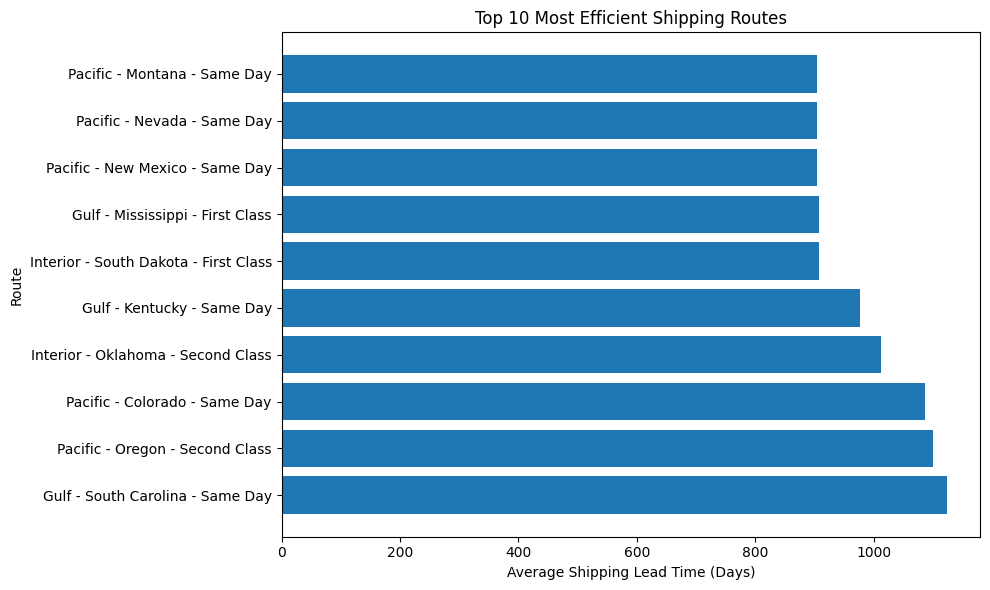

In [20]:
import matplotlib.pyplot as plt

# Top 10 most efficient routes
top_10 = route_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=True
).head(10)

# Create route labels
top_10["Route"] = (
    top_10["Region"] + " - " +
    top_10["State/Province"] + " - " +
    top_10["Ship Mode"]
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Route"],
    top_10["Average_Lead_Time"]
)

plt.xlabel("Average Shipping Lead Time (Days)")
plt.ylabel("Route")
plt.title("Top 10 Most Efficient Shipping Routes")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

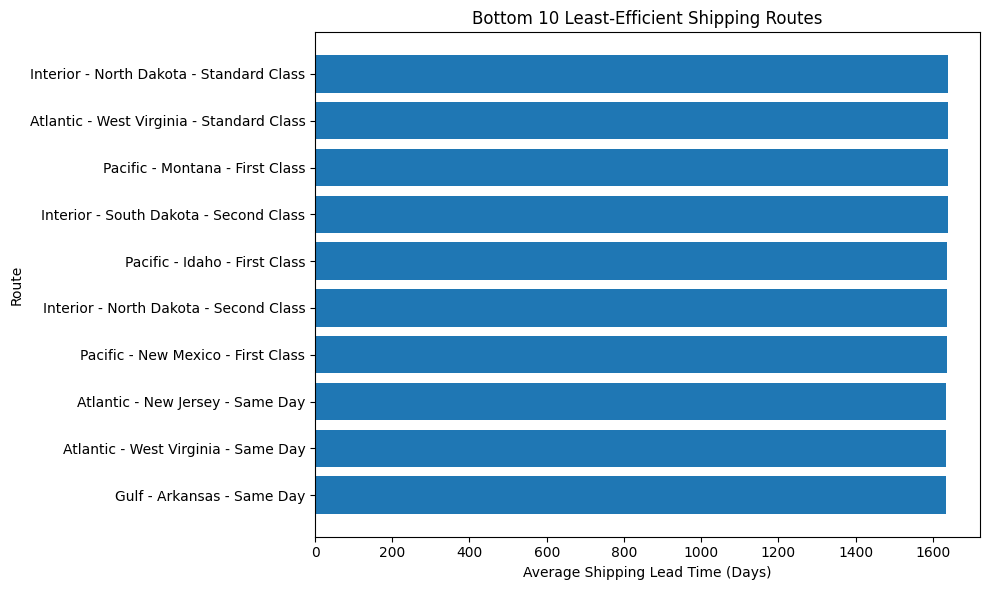

In [21]:
# Bottom 10 least-efficient routes

bottom_10 = route_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=False
).head(10)

# Create route labels
bottom_10["Route"] = (
    bottom_10["Region"] + " - " +
    bottom_10["State/Province"] + " - " +
    bottom_10["Ship Mode"]
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    bottom_10["Route"],
    bottom_10["Average_Lead_Time"]
)

plt.xlabel("Average Shipping Lead Time (Days)")
plt.ylabel("Route")
plt.title("Bottom 10 Least-Efficient Shipping Routes")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

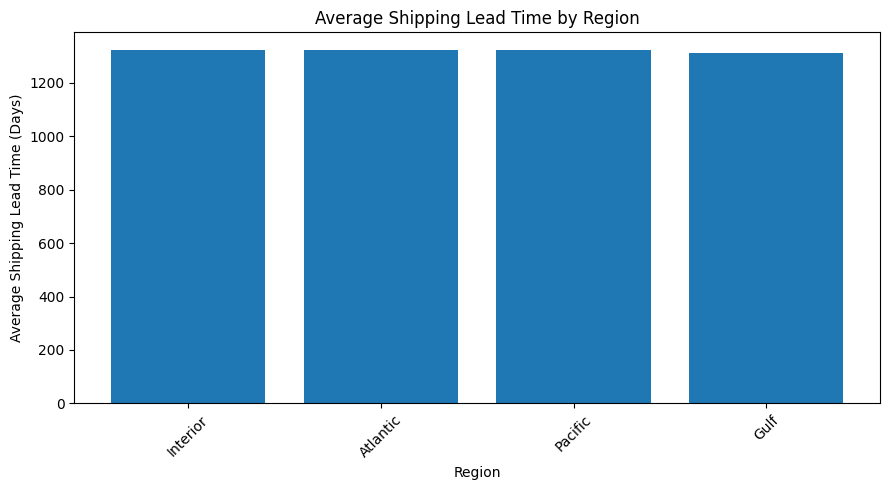

In [22]:
# Regional bottleneck analysis

region_chart = region_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    region_chart["Region"],
    region_chart["Average_Lead_Time"]
)

plt.xlabel("Region")
plt.ylabel("Average Shipping Lead Time (Days)")
plt.title("Average Shipping Lead Time by Region")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

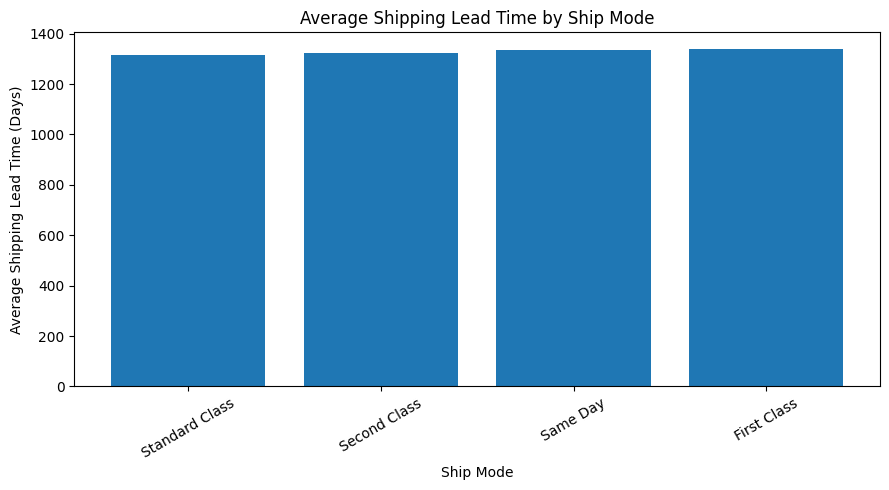

In [23]:
# Ship Mode Comparison

ship_mode_chart = ship_mode_analysis.sort_values(
    by="Average_Lead_Time"
)

plt.figure(figsize=(9, 5))

plt.bar(
    ship_mode_chart["Ship Mode"],
    ship_mode_chart["Average_Lead_Time"]
)

plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Lead Time (Days)")
plt.title("Average Shipping Lead Time by Ship Mode")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

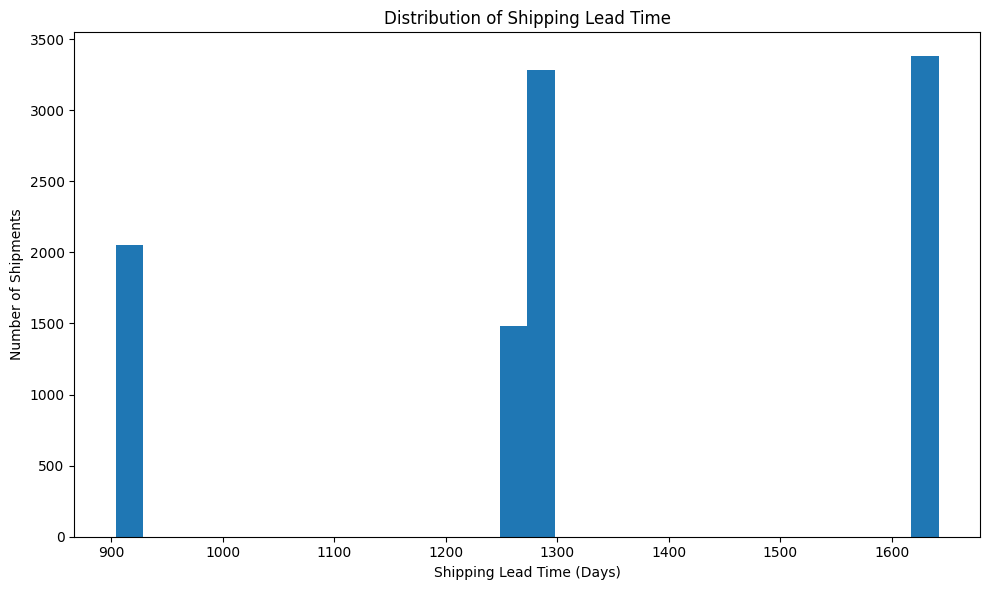

In [24]:
# Shipping Lead-Time Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df["Shipping Lead Time"],
    bins=30
)

plt.xlabel("Shipping Lead Time (Days)")
plt.ylabel("Number of Shipments")
plt.title("Distribution of Shipping Lead Time")

plt.tight_layout()
plt.show()